# Measures of Dispersion, Variability & Spread
### Naive Everyday Examples, Mathematical Formulations & Practical Python Implementations

> **Programme:** C-DAC PGCP-AI | **Course:** Data Analytics  
> **Author:** abs6187 (`23f2000876@ds.study.iitm.ac.in`)  

---

### Why Measures of Dispersion Matter:
While **Central Tendency** tells us where the middle of the data lies, it gives zero information about how spread out or concentrated the numbers are.

* **Example:** Two classrooms both have an average test score of **70%**:
  * *Classroom A:* Scores are `[68, 70, 71, 69, 72]` (Very consistent, low spread).
  * *Classroom B:* Scores are `[20, 50, 75, 95, 110]` (Wildly inconsistent, high spread).

Without measures of dispersion, you cannot distinguish Classroom A from Classroom B! Below are all primary measures of dispersion with everyday intuition, mathematical formulas, and Python code.


In [1]:
# Setup imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import math

# Set random seed for reproducibility
np.random.seed(42)
print("Libraries successfully imported!")


Libraries successfully imported!


---
## 1. Range (Peak-to-Peak Spread)

* **What it does:** Measures the total span between the largest and smallest values in the dataset.
* **Mathematical Notation:**
  $$\text{Range} = x_{\max} - x_{\min}$$
* **Everyday Naive Example:**
  Daily temperature forecast in Celsius: `[18, 21, 24, 26, 32]`
  $$\text{Range} = 32 - 18 = 14^\circ\text{C}$$
* **When to use:** Quick rough estimation of total spread.  
* **Major Limitation:** Extremely sensitive to single outliers (if one day hits 48°C, the range jumps to 30°C).


Data Points       : [18, 21, 24, 26, 32]
Minimum Value     : 18°C
Maximum Value     : 32°C
Range (Python)    : 14°C
Range (np.ptp)    : 14°C


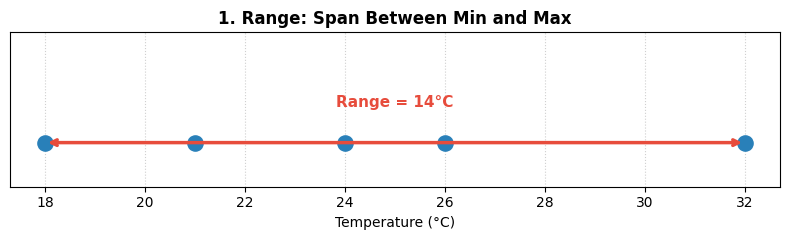

In [3]:
# 1. Range Example
temps = [18, 21, 24, 26, 32]

# Plain Python
range_python = max(temps) - min(temps)

# NumPy (np.ptp stands for 'peak-to-peak')
range_numpy = np.ptp(temps)

print("=" * 50)
print(f"Data Points       : {temps}")
print(f"Minimum Value     : {min(temps)}°C")
print(f"Maximum Value     : {max(temps)}°C")
print(f"Range (Python)    : {range_python}°C")
print(f"Range (np.ptp)    : {range_numpy}°C")
print("=" * 50)

# Visual representation of Range
plt.figure(figsize=(8, 2.5))
plt.scatter(temps, [1]*len(temps), color='#2980b9', s=120, zorder=3, label='Observations')
plt.annotate('', xy=(max(temps), 1), xytext=(min(temps), 1),
             arrowprops=dict(arrowstyle='<->', color='#e74c3c', lw=2.5))
plt.text((min(temps) + max(temps)) / 2, 1.08, f'Range = {range_numpy}°C', 
         ha='center', color='#e74c3c', fontweight='bold', fontsize=11)
plt.yticks([])
plt.xlabel('Temperature (°C)')
plt.title('1. Range: Span Between Min and Max', fontweight='bold')
plt.ylim(0.9, 1.25)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


---
## 2. Interquartile Range (IQR & Quartile Deviation)

* **What it does:** Measures the spread of the **middle 50%** of sorted observations, completely ignoring extreme high or low tails.
* **Mathematical Notation:**
  $$\text{IQR} = Q_3 - Q_1$$
  $$\text{Quartile Deviation (Semi-IQR)} = \frac{Q_3 - Q_1}{2}$$
  *Where:*
  * $Q_1$ (*25th percentile*): The median of the lower half.
  * $Q_3$ (*75th percentile*): The median of the upper half.
* **Everyday Naive Example:**
  Apartment rent in a neighborhood (sorted in \$k): `[10, 12, 14, 15, 18, 20, 22, 25, 95]` (9 houses)
  * $Q_1 = 13.0$, $Q_3 = 21.0$
  * $\text{IQR} = 21.0 - 13.0 = 8.0$ (The mansion at 95 does NOT distort the IQR!)
* **When to use:** Whenever data has heavy skewness, extreme outliers, or non-normal distribution.


Data Points (with outlier 95) : [10, 12, 14, 15, 18, 20, 22, 25, 95]
Q1 (25th Percentile)          : 14.0
Q2 (Median / 50th Percentile) : 18.0
Q3 (75th Percentile)          : 22.0
IQR (Q3 - Q1)                 : 8.0
Semi-IQR (Quartile Deviation) : 4.0


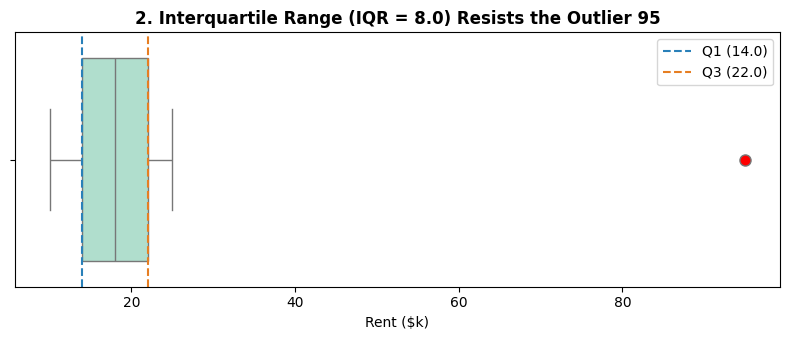

In [5]:
# 2. Interquartile Range (IQR)
rents = np.array([10, 12, 14, 15, 18, 20, 22, 25, 95])

# NumPy percentile calculation
q1 = np.percentile(rents, 25)
q2 = np.percentile(rents, 50)  # Median
q3 = np.percentile(rents, 75)
iqr_numpy = q3 - q1

# SciPy stats.iqr
iqr_scipy = stats.iqr(rents)
semi_iqr = iqr_scipy / 2.0

print("=" * 50)
print(f"Data Points (with outlier 95) : {rents.tolist()}")
print(f"Q1 (25th Percentile)          : {q1:.1f}")
print(f"Q2 (Median / 50th Percentile) : {q2:.1f}")
print(f"Q3 (75th Percentile)          : {q3:.1f}")
print(f"IQR (Q3 - Q1)                 : {iqr_numpy:.1f}")
print(f"Semi-IQR (Quartile Deviation) : {semi_iqr:.1f}")
print("=" * 50)

# Visual representation via Boxplot
plt.figure(figsize=(8, 3.5))
sns.boxplot(x=rents, color='#a8e6cf', flierprops={'marker':'o', 'markerfacecolor':'red', 'markersize':8})
plt.axvline(q1, color='#2980b9', linestyle='--', label=f'Q1 ({q1:.1f})')
plt.axvline(q3, color='#e67e22', linestyle='--', label=f'Q3 ({q3:.1f})')
plt.title(f'2. Interquartile Range (IQR = {iqr_numpy:.1f}) Resists the Outlier 95', fontweight='bold')
plt.xlabel('Rent ($k)')
plt.legend()
plt.tight_layout()
plt.show()


---
## 3. Variance (Population $\sigma^2$ vs. Sample $s^2$)

* **What it does:** Calculates the **average squared distance** of every observation from the mean.
* **Mathematical Notation:**
  * **Population Variance ($\sigma^2$):** Used when you have 100% of the entire population:
    $$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2$$
  * **Sample Variance ($s^2$):** Used when estimating from a sample drawn from a larger population:
    $$s^2 = \frac{1}{n - 1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$
* **Why divide by $n - 1$ instead of $n$? (Bessel's Correction):**
  Sample points naturally cluster closer to their own sample mean $\bar{x}$ than to the true unknown population mean $\mu$. Dividing by $n$ would systematically underestimate true variance. Dividing by $n - 1$ removes this bias.
* **Everyday Naive Example:**
  Delivery times for 5 pizzas: `[20, 22, 25, 28, 30]` minutes (Mean $\bar{x} = 25$ min).
  * Deviations from 25: `[-5, -3, 0, +3, +5]`
  * Squared deviations: `[25, 9, 0, 9, 25]` $\implies \sum = 68$
  * Sample Variance: $s^2 = \frac{68}{5 - 1} = \frac{68}{4} = 17.0\text{ minutes}^2$
* **Limitation of Variance:** The units are squared (e.g. $\text{minutes}^2$, \$^2$), which is unintuitive in business.


Delivery Times (minutes)  : [20, 22, 25, 28, 30]
Mean Delivery Time        : 25.0 minutes
Squared Deviations (x-μ)² : [25.0, 9.0, 0.0, 9.0, 25.0]
Sum of Squared Diffs (SSD): 68.0
------------------------------------------------------------
Sample Variance (s², n-1) : 17.00 min²  (Unbiased)
Population Variance (σ², n): 13.60 min²  (Biased for samples)


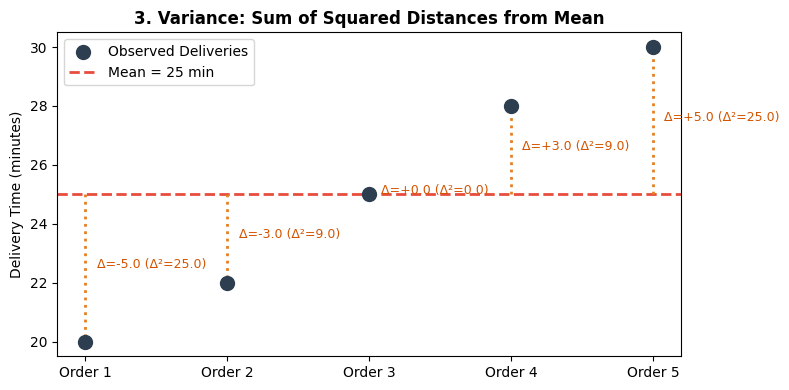

In [7]:
# 3. Variance Example
delivery = [20, 22, 25, 28, 30]
x_bar = sum(delivery) / len(delivery)

# Step-by-step Plain Python
squared_diffs = [(x - x_bar)**2 for x in delivery]
sample_var_python = sum(squared_diffs) / (len(delivery) - 1)
pop_var_python = sum(squared_diffs) / len(delivery)

# NumPy implementation (ddof = Delta Degrees of Freedom)
sample_var_numpy = np.var(delivery, ddof=1)  # Bessel's correction
pop_var_numpy = np.var(delivery, ddof=0)     # Population formula

print("=" * 60)
print(f"Delivery Times (minutes)  : {delivery}")
print(f"Mean Delivery Time        : {x_bar:.1f} minutes")
print(f"Squared Deviations (x-μ)² : {squared_diffs}")
print(f"Sum of Squared Diffs (SSD): {sum(squared_diffs)}")
print("-" * 60)
print(f"Sample Variance (s², n-1) : {sample_var_numpy:.2f} min²  (Unbiased)")
print(f"Population Variance (σ², n): {pop_var_numpy:.2f} min²  (Biased for samples)")
print("=" * 60)

# Visualization of squared deviations
fig, ax = plt.subplots(figsize=(8, 4))
indices = range(len(delivery))
ax.scatter(indices, delivery, color='#2c3e50', s=100, zorder=3, label='Observed Deliveries')
ax.axhline(x_bar, color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean = {x_bar:.0f} min')
for i, val in enumerate(delivery):
    ax.vlines(i, x_bar, val, color='#e67e22', linestyle=':', linewidth=2)
    diff = val - x_bar
    ax.text(i + 0.08, (val + x_bar)/2, f'Δ={diff:+.1f} (Δ²={diff**2:.1f})', fontsize=9, color='#d35400')
ax.set_xticks(list(indices))
ax.set_xticklabels([f'Order {i+1}' for i in indices])
ax.set_ylabel('Delivery Time (minutes)')
ax.set_title('3. Variance: Sum of Squared Distances from Mean', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
## 4. Standard Deviation ($s$ and $\sigma$)

* **What it does:** The square root of variance. It restores the dispersion metric back into the **exact original units** of the data.
* **Mathematical Notation:**
  * **Sample Standard Deviation:** $s = \sqrt{s^2} = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n - 1}}$
  * **Population Standard Deviation:** $\sigma = \sqrt{\sigma^2} = \sqrt{\frac{\sum (x_i - \mu)^2}{N}}$
* **The Empirical 68–95–99.7% Rule (For Normal Distributions):**
  * $\approx 68.27\%$ of observations fall within $\bar{x} \pm 1s$
  * $\approx 95.45\%$ of observations fall within $\bar{x} \pm 2s$
  * $\approx 99.73\%$ of observations fall within $\bar{x} \pm 3s$
* **Everyday Naive Example:**
  For the pizza deliveries with $s^2 = 17.0\text{ min}^2$:
  $$s = \sqrt{17.0} \approx 4.12\text{ minutes}$$
  *Business Interpretation:* "On average, our delivery times fluctuate by approximately **$\pm 4.1$ minutes** around the 25-minute average."


Sample Variance (s²)       : 17.00 min²
Sample Standard Deviation  : 4.12 minutes (√17.0)
Population Std Deviation   : 3.69 minutes


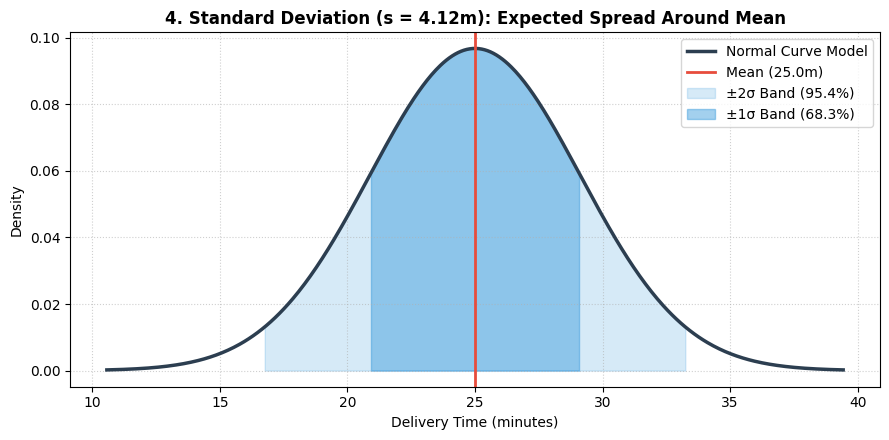

In [9]:
# 4. Standard Deviation
sample_std = np.std(delivery, ddof=1)
pop_std = np.std(delivery, ddof=0)

print("=" * 55)
print(f"Sample Variance (s²)       : {sample_var_numpy:.2f} min²")
print(f"Sample Standard Deviation  : {sample_std:.2f} minutes (√17.0)")
print(f"Population Std Deviation   : {pop_std:.2f} minutes")
print("=" * 55)

# Visualizing the 1-Std and 2-Std Empirical Bands
norm_x = np.linspace(x_bar - 3.5*sample_std, x_bar + 3.5*sample_std, 500)
norm_pdf = stats.norm.pdf(norm_x, loc=x_bar, scale=sample_std)

plt.figure(figsize=(9, 4.5))
plt.plot(norm_x, norm_pdf, color='#2c3e50', lw=2.5, label='Normal Curve Model')
plt.axvline(x_bar, color='#e74c3c', lw=2, label=f'Mean ({x_bar:.1f}m)')

# Shading 1-sigma and 2-sigma bands
mask_1s = (norm_x >= x_bar - sample_std) & (norm_x <= x_bar + sample_std)
mask_2s = (norm_x >= x_bar - 2*sample_std) & (norm_x <= x_bar + 2*sample_std)
plt.fill_between(norm_x[mask_2s], norm_pdf[mask_2s], color='#3498db', alpha=0.2, label='±2σ Band (95.4%)')
plt.fill_between(norm_x[mask_1s], norm_pdf[mask_1s], color='#3498db', alpha=0.45, label='±1σ Band (68.3%)')

plt.title(f'4. Standard Deviation (s = {sample_std:.2f}m): Expected Spread Around Mean', fontweight='bold')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


---
## 5. Mean & Median Absolute Deviation (MAD)

* **What it does:** Measures the average **linear distance** from the center, avoiding the distortion caused by squaring errors.
* **Mathematical Notation:**
  * **Mean Absolute Deviation (Mean MAD):**
    $$\text{MAD}_{\text{mean}} = \frac{1}{n} \sum_{i=1}^{n} |x_i - \bar{x}|$$
  * **Median Absolute Deviation (Median MAD):**
    $$\text{MAD}_{\text{median}} = \text{median}\left( |x_i - \tilde{x}| \right)$$
* **Why use it over Standard Deviation?**
  Squaring in standard deviation gives huge disproportionate weight to outliers. Absolute deviations grow linearly, making MAD far more robust in sensor networks and algorithmic trading.


In [11]:
# 5. MAD Comparison on Data with an Outlier
salaries = np.array([45, 50, 52, 55, 60, 250])  # in $k, 250 is an executive outlier

# Mean MAD
mean_mad = np.mean(np.abs(salaries - np.mean(salaries)))

# Median MAD (SciPy implementation)
median_mad = stats.median_abs_deviation(salaries)
std_salaries = np.std(salaries, ddof=1)

print("=" * 60)
print(f"Dataset with Outlier         : {salaries.tolist()}")
print(f"Mean Salary                  : ${np.mean(salaries):.1f}k")
print(f"Median Salary                : ${np.median(salaries):.1f}k")
print("-" * 60)
print(f"Standard Deviation (s)       : ${std_salaries:.1f}k (Distorted by 250 outlier!)")
print(f"Mean Absolute Deviation (MAD): ${mean_mad:.1f}k (Linear distance)")
print(f"Median Absolute Dev (MAD_med): ${median_mad:.1f}k (Extremely robust!)")
print("=" * 60)


Dataset with Outlier         : [45, 50, 52, 55, 60, 250]
Mean Salary                  : $85.3k
Median Salary                : $53.5k
------------------------------------------------------------
Standard Deviation (s)       : $80.8k (Distorted by 250 outlier!)
Mean Absolute Deviation (MAD): $54.9k (Linear distance)
Median Absolute Dev (MAD_med): $5.0k (Extremely robust!)


---
## 6. Coefficient of Variation (CV — Relative Dispersion)

* **What it does:** Expresses standard deviation as a **percentage of the mean**, creating a completely unitless measure of relative risk and volatility.
* **Mathematical Notation:**
  $$CV = \left( \frac{s}{\bar{x}} \right) \times 100\%$$
* **Why CV is Essential in Business:**
  Raw standard deviation cannot compare things measured in different units (e.g. height in cm vs weight in kg) or things at completely different scales.
* **Everyday Naive Example:**
  * *Stock A (Penny Stock):* Mean price = **\$10**, $s = \mathbf{\$2}$
    $$CV_A = \frac{2}{10} \times 100\% = \mathbf{20.0\%}$$
  * *Stock B (Tech Giant):* Mean price = **\$1,000**, $s = \mathbf{\$50}$
    $$CV_B = \frac{50}{1000} \times 100\% = \mathbf{5.0\%}$$
  * **Verdict:** Even though Stock B has a much larger raw dollar standard deviation (\$50 vs \$2), Stock A is **$4\times$ more volatile and risky** relative to its value!


       COEFFICIENT OF VARIATION (CV) INVESTMENT COMPARISON     
Stock A (Penny)    : Mean = $10.04, Std = $1.96 -> CV = 19.51%
Stock B (Blue Chip): Mean = $1003.54, Std = $49.87 -> CV = 4.97%
-----------------------------------------------------------------
Risk Comparison    : Stock A is 3.9x MORE volatile than Stock B!


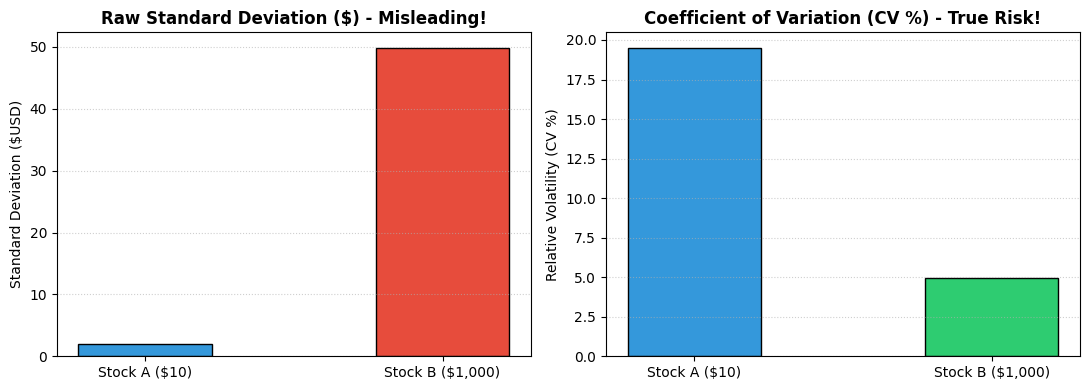

In [13]:
# 6. Coefficient of Variation (CV) Investment Risk Comparison
stock_a = np.random.normal(loc=10.0, scale=2.0, size=1000)   # Penny Stock
stock_b = np.random.normal(loc=1000.0, scale=50.0, size=1000) # Blue Chip

cv_a = (np.std(stock_a, ddof=1) / np.mean(stock_a)) * 100
cv_b = (np.std(stock_b, ddof=1) / np.mean(stock_b)) * 100

print("=" * 65)
print("       COEFFICIENT OF VARIATION (CV) INVESTMENT COMPARISON     ")
print("=" * 65)
print(f"Stock A (Penny)    : Mean = ${np.mean(stock_a):.2f}, Std = ${np.std(stock_a, ddof=1):.2f} -> CV = {cv_a:.2f}%")
print(f"Stock B (Blue Chip): Mean = ${np.mean(stock_b):.2f}, Std = ${np.std(stock_b, ddof=1):.2f} -> CV = {cv_b:.2f}%")
print("-" * 65)
print(f"Risk Comparison    : Stock A is {cv_a / cv_b:.1f}x MORE volatile than Stock B!")
print("=" * 65)

# Visual Comparison Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(['Stock A ($10)', 'Stock B ($1,000)'], [np.std(stock_a, ddof=1), np.std(stock_b, ddof=1)], 
            color=['#3498db', '#e74c3c'], width=0.45, edgecolor='black')
axes[0].set_title('Raw Standard Deviation ($) - Misleading!', fontweight='bold')
axes[0].set_ylabel('Standard Deviation ($USD)')
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

axes[1].bar(['Stock A ($10)', 'Stock B ($1,000)'], [cv_a, cv_b], 
            color=['#3498db', '#2ecc71'], width=0.45, edgecolor='black')
axes[1].set_title('Coefficient of Variation (CV %) - True Risk!', fontweight='bold')
axes[1].set_ylabel('Relative Volatility (CV %)')
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


---
## 7. Master Summary: Selecting the Right Measure of Dispersion

| Measure of Dispersion | Mathematical Formula | Sensitivity to Outliers | Primary Use Case |
| :--- | :---: | :---: | :--- |
| **Range** | $x_{\max} - x_{\min}$ | Extremely High | Quick sanity check of overall span. |
| **Interquartile Range (IQR)** | $Q_3 - Q_1$ | Very Low (Robust) | Boxplots, skewed data, income & housing prices. |
| **Variance ($s^2$)** | $\frac{\sum (x_i - \bar{x})^2}{n - 1}$ | Very High | Mathematical derivations, ANOVA, ML loss functions. |
| **Standard Deviation ($s$)** | $\sqrt{s^2}$ | Moderate-High | Normal distributions, Six Sigma quality control. |
| **Median Abs. Dev. (MAD)** | $\text{median}(|x_i - \tilde{x}|)$ | Extremely Low | Robust non-parametric scale estimation. |
| **Coefficient of Variation ($CV$)** | $\frac{s}{\bar{x}} \times 100\%$ | Dependent on $s$ | Comparing volatility across different currencies or metrics. |
